In [ ]:
# Cell 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install onnxruntime opencv-python-headless pycpd

In [ ]:
import onnxruntime as rt
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import os
from google.colab.patches import cv2_imshow
from pycpd import RigidRegistration
import inspect

In [ ]:
INPUT_SIZE = 704
CONFIDENCE_THRESHOLD = 0.80 # yeah we're bumping it up

px_to_step_x = 1.576 # need to fine-tune --> these are just approx, can be better
px_to_step_y = 1.668 # need to fine-tune --> these are just approx, can be better

um_to_pixel_scalar_x = 3840/1037  # not used
um_to_pixel_scalar_y = 2160/583   # not used

In [ ]:
################################ ACTUAL FUNCTIONS ################################
def detect_marks_for_slam(img, session, orig_h, orig_w, threshold=0.77) -> list[dict]:
  """
  Detects alignment markers for tiling SLAM algorithm
  Returns an array of dictionary coordinates such that
  - `arr[i] = {"center": (x,y), "left":(x,y), "right":(x,y), "top":(x,y), "bottom":(x,y)}`
  """
  vis = img.copy()
  # assert (vis.shape[2]) <= 3, "bad image color dimensions"

  # Run inference with our weights
  input_name = session.get_inputs()[0].name
  boxes, scores = session.run(None, {input_name: img})

  # collect good matches
  boxes = boxes[0]
  scores = scores[0]

  markers = []
  for i in range(len(boxes)):
      class_id = np.argmax(scores[i])
      confidence = 1 / (1 + np.exp(-scores[i][class_id]))
      if confidence > threshold:
          x, y, w, h = boxes[i]

          # fetch centers, and scale back to orig_img size
          cx = int(x * orig_w)
          cy = int(y * orig_h)
          bw = int(w * orig_w)
          bh = int(h * orig_h)

          marker = {
              "center": (cx, cy),
              "left":   (cx - bw // 2, cy),
              "right":  (cx + bw // 2, cy),
              "top":    (cx, cy - bh // 2),
              "bottom": (cx, cy + bh // 2)
          }
          markers.append(marker)
  return markers

In [ ]:
def rf_detr_preprocess(img, layer: int = 1):
    if img is None:
        raise Exception("Error: image is None")
    if img.mode != 'RGB':
        img = img.convert('RGB')

    processed = np.array(img)

    orig_h, orig_w = processed.shape[:2]
    img_resized = cv2.resize(processed, (INPUT_SIZE, INPUT_SIZE))
    img_input = img_resized.transpose(2, 0, 1)                          # HWC -> CHW
    img_input = np.expand_dims(img_input, 0).astype(np.float32) / 255.0

    return img_input, orig_h, orig_w

In [ ]:
def visualize_detected_marks(img, marks_raw, title="Detected Marks"):
    fig, ax = plt.subplots(1, 1, figsize=(10, 15))
    ax.imshow(img)
    ax.set_title(f"{title}\n({len(marks_raw)} markers detected)", fontsize=12)

    colors = plt.cm.rainbow(np.linspace(0, 1, max(len(marks_raw), 1)))

    for i, mark in enumerate(marks_raw):
        cx, cy = mark["center"]
        color = colors[i]

        # Bounding box (only if cardinal points exist)
        if all(k in mark for k in ("left", "right", "top", "bottom")):
            bw = mark["right"][0] - mark["left"][0]
            bh = mark["bottom"][1] - mark["top"][1]
            rect = patches.Rectangle(
                (cx - bw//2, cy - bh//2), bw, bh,
                linewidth=2, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)

            # Cardinal points
            for key, point in mark.items():
                if key == "center":
                    continue
                ax.plot(*point, '.', color=color, markersize=6)

        # Center crosshair
        ax.plot(cx, cy, '+', color=color, markersize=14, markeredgewidth=2)

        # Label
        ax.annotate(
            f"#{i}  ({cx}, {cy})",
            (cx, cy),
            textcoords="offset points", xytext=(8, 8),
            fontsize=8, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7)
        )

    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Visualization callback
def visualize(iteration, error, X, Y):
    plt.cla()
    plt.scatter(X[:, 0], X[:, 1], c='red',  label='Fixed / digital (X)')
    plt.scatter(Y[:, 0], Y[:, 1], c='blue', label='Moving / stitched (Y)')
    plt.title(f"Iter {iteration}  |  error {error:.4f}")
    plt.legend(); plt.pause(0.01)

# Align markers in stitched image to those in digital image using CPD registration
def align_stitched_to_digital(stitched_marks_centers, digital_marks_centers, visualize=False):
  digital = digital_marks_centers     # fixed target
  stitched = stitched_marks_centers   # moving source
  print(f"X (fixed,  digital):  {digital.shape} points")
  print(f"Y (moving, stitched): {stitched.shape} points")

  # CPD registration
  reg = RigidRegistration(X=digital, Y=stitched)

  if visualize:
    transformed_stitched, (s, R_est, t_est) = reg.register(callback=visualize)
    plt.show()
  else:
    transformed_stitched, (s, R_est, t_est) = reg.register()

  matches = np.argmax(reg.P, axis=1) # matches[i] = index in X that Y[i] maps to

  # TY  == s * Y @ R_est.T + t_est   (stitched marks in digital space)
  print(f"Estimated scale : {s}")
  print(f"Estimated rotation {R_est}")
  print(f"Estimated translation: {t_est}")
  print(f"Matches: {matches}")

  # ── Verify alignment ────────────────────────────────────────────────────────
  if visualize:
    fig, ax = plt.subplots()
    ax.scatter(digital[:, 0], digital[:, 1], c='red', label='Digital (fixed)')
    ax.scatter(transformed_stitched[:, 0], transformed_stitched[:, 1], c='green', label='Stitched aligned (TY)')
    ax.set_aspect('equal'); ax.legend(); plt.show()

  return (s, R_est, t_est, matches)

In [ ]:
def sort_stitched_alignment_markers(matches, stitched):
  stitched_sorted = np.zeros(shape=(len(matches), 2))
  for idx in range(len(stitched_sorted)):
    stitched_sorted[matches[idx]] = stitched[idx]
  return stitched_sorted

In [ ]:
# Apply transform onto stitched image

def apply_transform_on_stitched_img(stitched_pattern, digital_pattern, s, R_est, t_est):
  stitched_img = np.array(stitched_pattern)
  digital_img = np.array(digital_pattern)

  h_stitched, w_stitched = stitched_img.shape[:2]
  h_digital, w_digital = digital_img.shape[:2]

  # affine transform
  # After registration, compute output canvas bounds
  corners = np.array([[0,0],[w_stitched,0],[0,h_stitched],[w_stitched,h_stitched]], dtype=np.float32)
  corners_transformed = (s * (corners @ R_est)) + t_est

  all_x = np.concatenate([corners_transformed[:,0], [0, w_digital]])
  all_y = np.concatenate([corners_transformed[:,1], [0, h_digital]])

  x_min, x_max = all_x.min(), all_x.max()
  y_min, y_max = all_y.min(), all_y.max()

  # Offset so nothing goes off-canvas
  offset_x = max(0, -int(np.floor(x_min)))
  offset_y = max(0, -int(np.floor(y_min)))

  out_w = int(np.ceil(x_max)) + offset_x
  out_h = int(np.ceil(y_max)) + offset_y

  # Adjust translation to include the offset
  R_corrected = R_est.copy()
  R_corrected[0, 1] *= -1
  R_corrected[1, 0] *= -1

  M = np.zeros((2, 3))
  M[:, :2] = s * R_corrected
  M[:,  2] = t_est + np.array([offset_x, offset_y])

  print(f"Output canvas: {out_w} x {out_h},  offset: ({offset_x}, {offset_y})")

  warped = cv2.warpAffine(
      stitched_img,
      M,
      (out_w, out_h),
      flags=cv2.INTER_LINEAR,
  )

  warped_h, warped_w = warped.shape[:2]
  print(f"Warped image: {warped_w} x {warped_h}")

  # Also shift digital image to same canvas for overlay
  digital_canvas = np.zeros((out_h, out_w, 4), dtype=np.uint8)
  digital_canvas[offset_y:offset_y+h_digital, offset_x:offset_x+w_digital] = digital_img

  # Blend overlay
  overlay = cv2.addWeighted(digital_canvas, 0.5, warped, 0.5, 0)
  cv2_imshow(overlay)

[[ 110.   73.]
 [2385.   74.]
 [ 111. 1331.]
 [2387. 1331.]]
number of markers detected: 4
number of markers detected: 4
X (fixed,  digital):  (4, 2) points
Y (moving, stitched): (4, 2) points
Estimated scale : 7.320766769778279
Estimated rotation [[ 0.99938125  0.03517267]
 [-0.03517267  0.99938125]]
Estimated translation: [-484.63244238 -325.67735234]
Matches: [2 3 1 0]


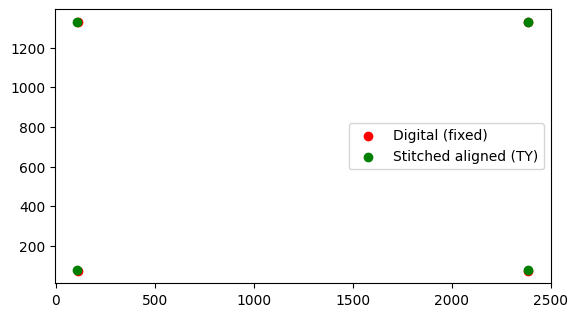

scale: 7.320766769778279
R_est: [[ 0.99938125  0.03517267]
 [-0.03517267  0.99938125]]
t_est: [-484.63244238 -325.67735234]
matches: [2 3 1 0]
Output canvas: 3621 x 2160,  offset: (557, 326)
Warped image: 3621 x 2160


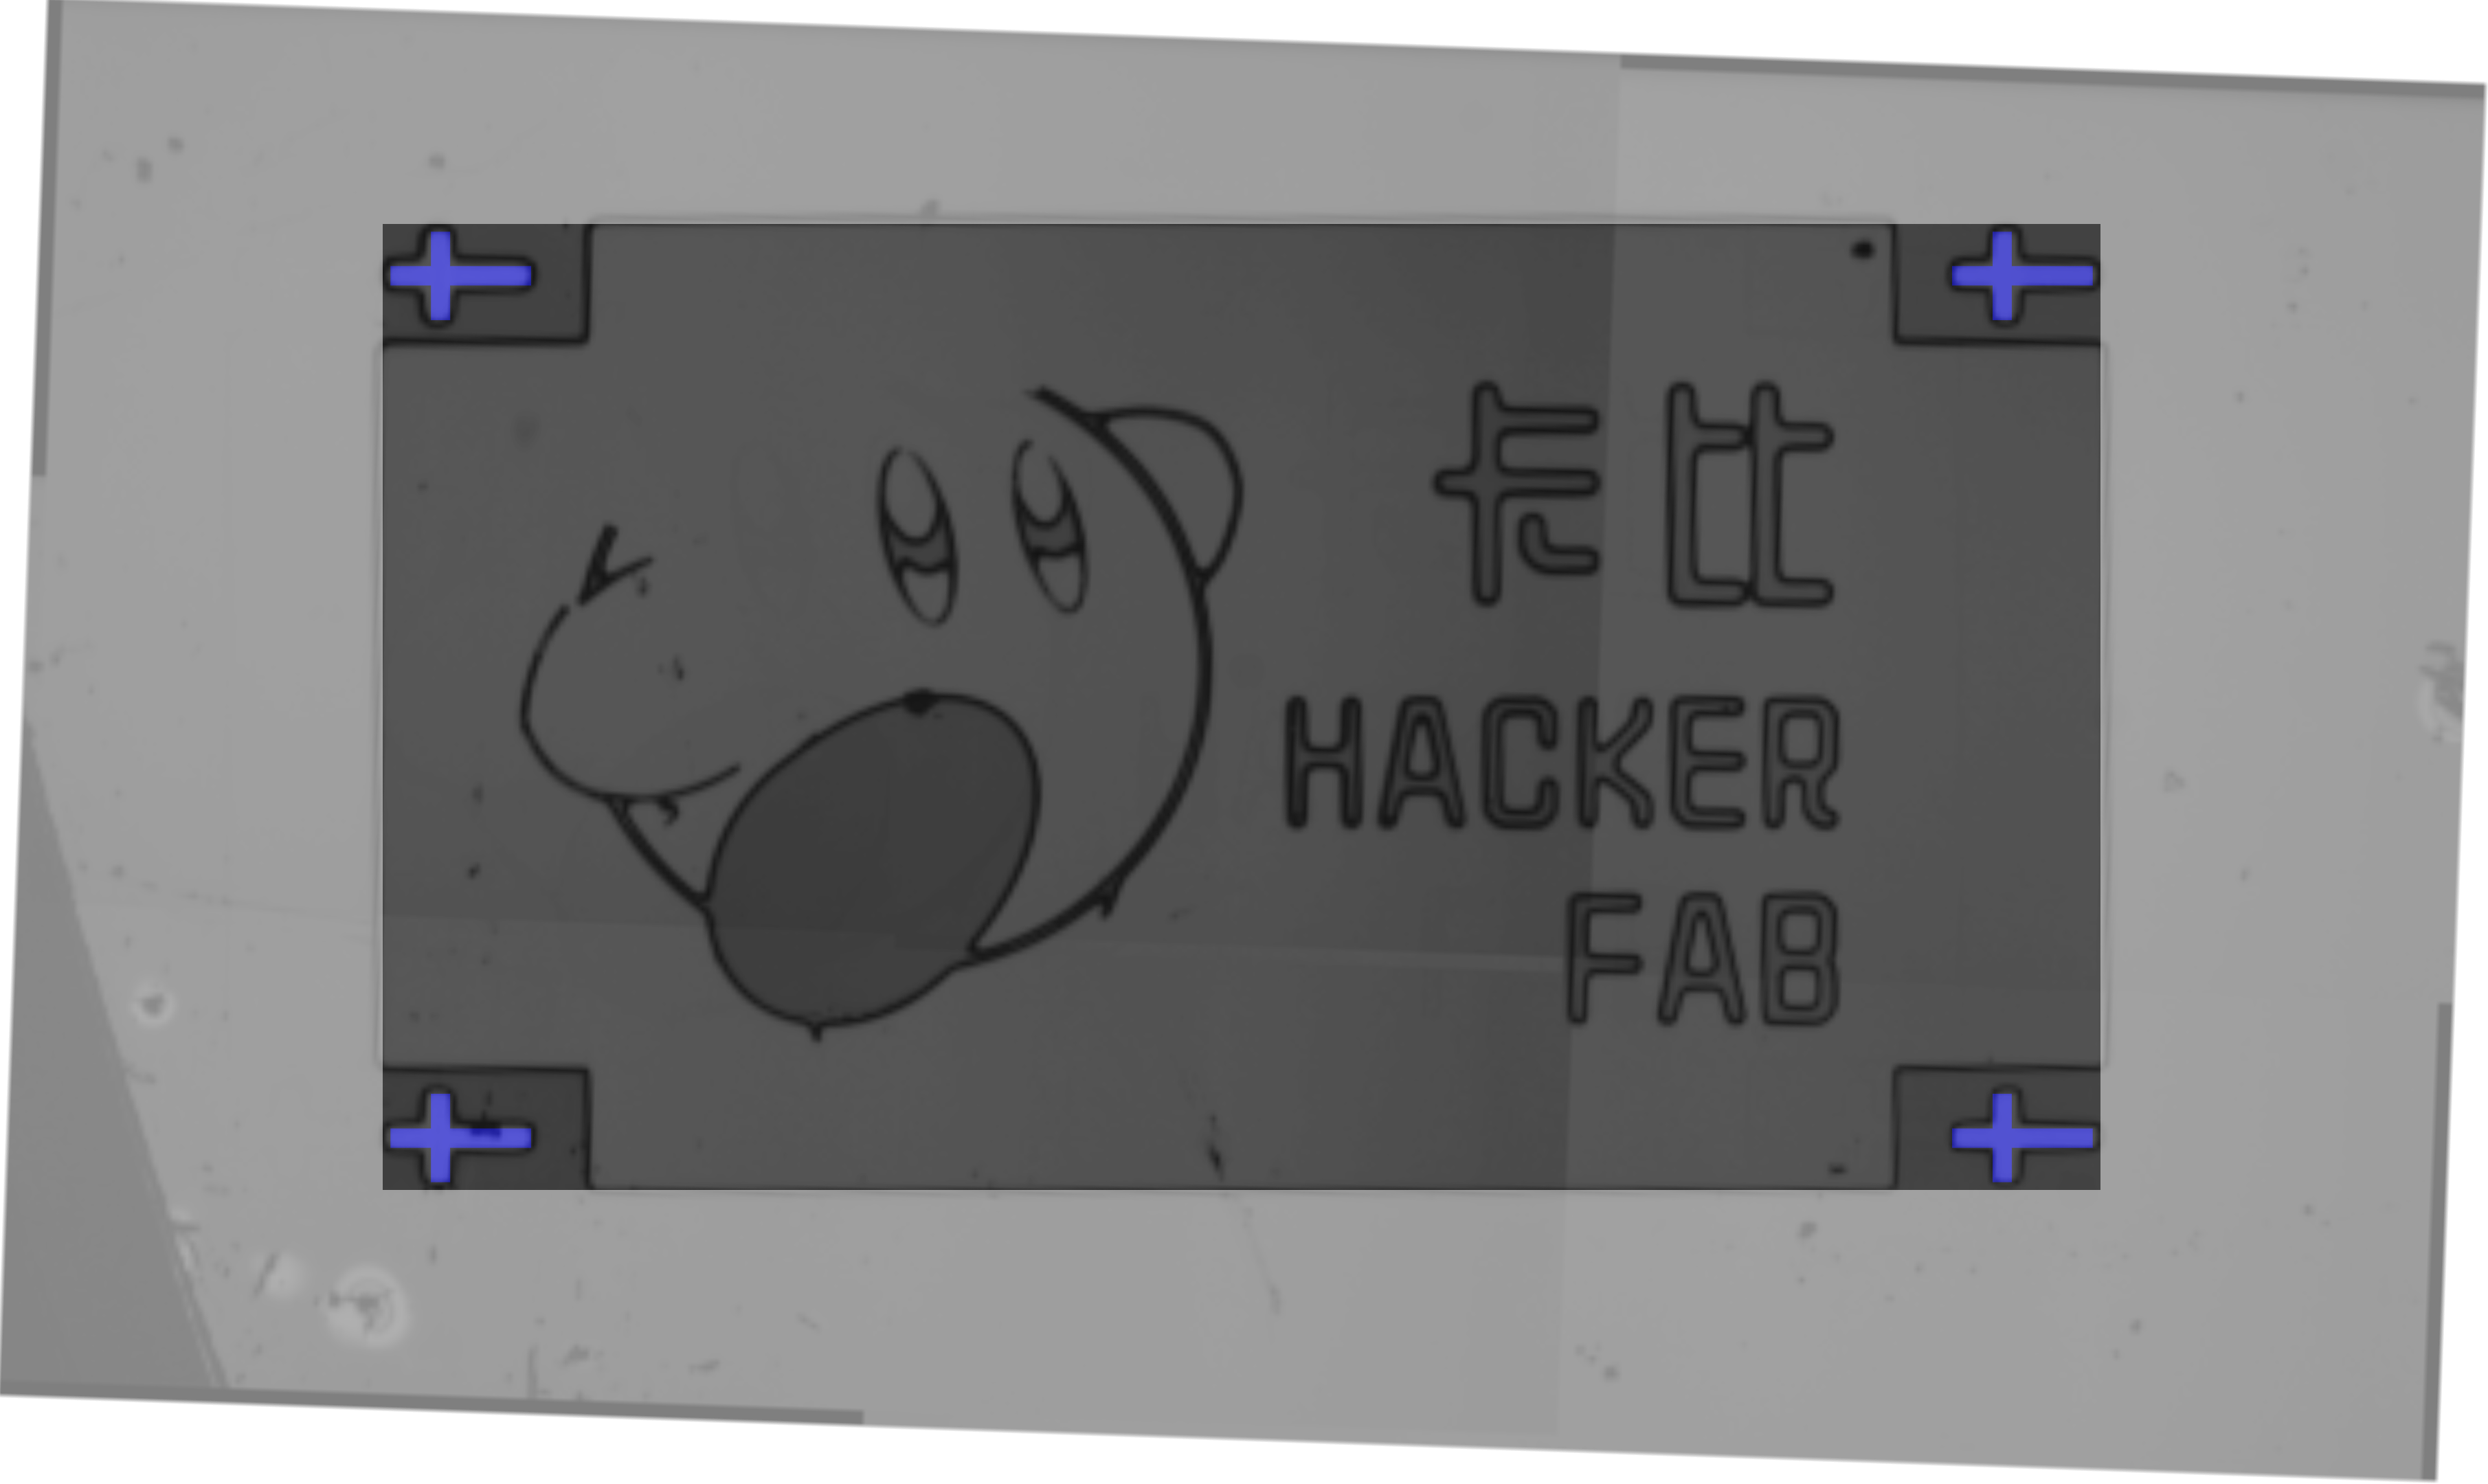

sorted_stitched_marks: [[ 83.  52.]
 [394.  41.]
 [ 89. 223.]
 [400. 212.]]
rad of rotation: -2.015661506578828


In [ ]:
if __name__ == "__main__":
  session = rt.InferenceSession(r"/content/drive/Shareddrives/Hacker Fab Students/Hacker Fab Students/Projects/Spring 2026 Projects/Stepper/Checkpoint 3/weights.onnx")
  directory = "/content/drive/Shareddrives/Hacker Fab Students/Hacker Fab Students/Projects/Spring 2026 Projects/Stepper/Checkpoint 3/multilayer_test_data"
  kirby_file_1 = "data_collection_kirby_20260411_193338.png"
  kirby_file_2 = "data_collection_kirby_20260411_194311.png"
  kirby_file_3 = "data_collection_kirby_20260411_194339.png"
  non_flipped_kirby_file = "stuffff.png"
  stitched_pattern_path = os.path.join(directory, non_flipped_kirby_file)
  stitched_pattern = Image.open(stitched_pattern_path)
  processed_stitched_pattern, orig_h, orig_w = rf_detr_preprocess(stitched_pattern, layer=2)
  stitched_marks = detect_marks_for_slam(processed_stitched_pattern, session, orig_h, orig_w)

  digital_pattern_path = os.path.join(directory, "alignment_marks.png")
  digital_pattern = Image.open(digital_pattern_path)
  processed_digital_pattern, orig_h, orig_w = rf_detr_preprocess(digital_pattern, layer=2)
  digital_marks = detect_marks_for_slam(processed_digital_pattern, session, orig_h, orig_w)

  stitched_marks = np.array([mark["center"] for mark in stitched_marks]).astype(np.float32)
  digital_marks = np.array([mark["center"] for mark in digital_marks]).astype(np.float32)

  # sort in row-major order
  sorted_digital_marks = np.array(sorted(digital_marks, key=lambda item: (item[1], item[0])))
  print(sorted_digital_marks)

  # visualize_detected_marks(stitched_pattern, stitched_marks, title="Stitched Pattern")
  # visualize_detected_marks(digital_pattern, digital_marks, title="Digital Pattern")

  print(f"number of markers detected: {len(stitched_marks)}")
  print(f"number of markers detected: {len(digital_marks)}")

  s, R_est, t_est, matches = align_stitched_to_digital(stitched_marks, sorted_digital_marks, True)
  sorted_stitched_marks = sort_stitched_alignment_markers(matches, stitched_marks)
  print(f"scale: {s}")
  print(f"R_est: {R_est}")
  print(f"t_est: {t_est}")
  print(f"matches: {matches}")

  apply_transform_on_stitched_img(stitched_pattern, digital_pattern, s, R_est, t_est)
  print(f"sorted_stitched_marks: {sorted_stitched_marks}")

  angle_rad = np.arctan2(R_est[1, 0], R_est[0, 0])
  angle_deg = np.degrees(angle_rad)
  print(f"rad of rotation: {angle_deg}")


# RANSAC for partial matching (unused for now)

Y shape: (3, 2),  X shape: (4, 2)
Y range: x=7–318, y=97–265
X range: x=110–2387, y=73–1331
Auto inlier_threshold: 628.75
  iter    0: new best 1/3 inliers  s=5.575
  iter    1: new best 3/3 inliers  s=7.441
Perfect match found early — stopping.

RANSAC best: 3/3 inliers
Scale:       7.441025
Rotation:
  [[ 0.99938181  0.03515746]
 [-0.03515746  0.99938181]]
Translation: [  -5.19812994 -643.0733083 ]
Inliers:     3 / 3


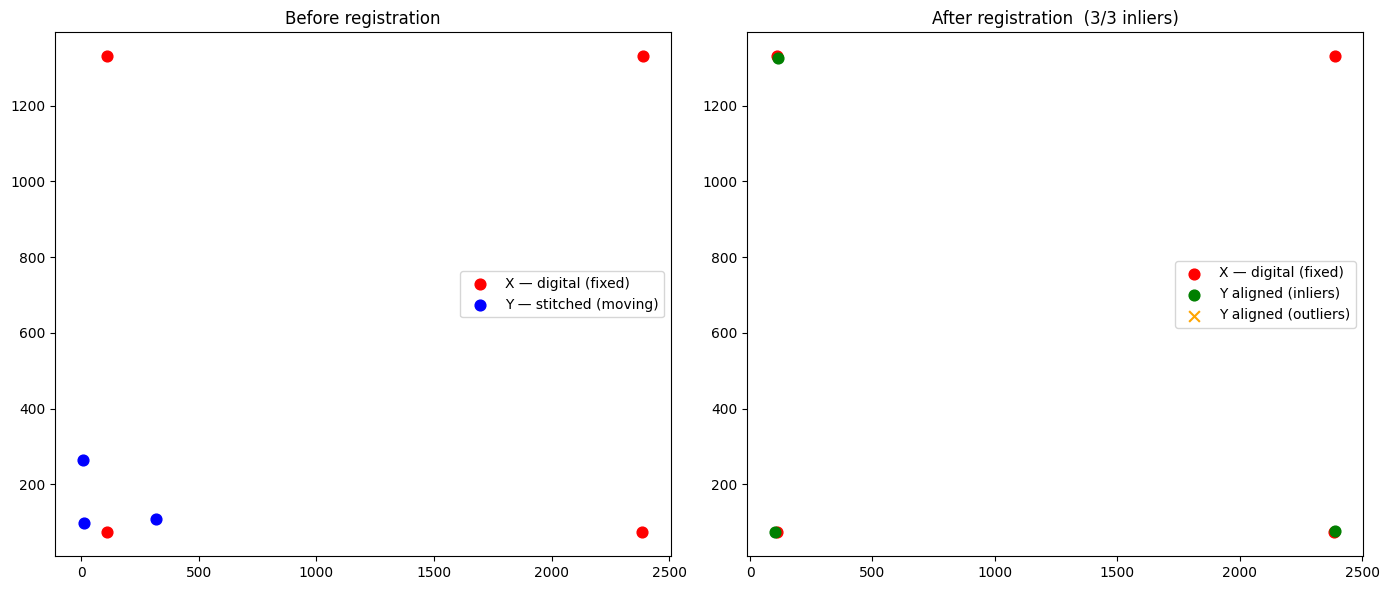

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from itertools import combinations

# ── Robust Partial Registration ─────────────────────────────────────────────

def apply_transform(Y, s, R, t):
    """Apply similarity transform: s * Y @ R.T + t"""
    return s * (Y @ R.T) + t

def estimate_transform_from_pairs(src_pts, dst_pts):
    """
    Estimate scale, rotation, translation from paired 2D points
    using Umeyama's method (closed-form similarity transform).
    """
    n = src_pts.shape[0]
    mu_s = src_pts.mean(axis=0)
    mu_d = dst_pts.mean(axis=0)

    src_c = src_pts - mu_s
    dst_c = dst_pts - mu_d

    var_s = (src_c ** 2).sum() / n

    H = src_c.T @ dst_c / n
    U, D, Vt = np.linalg.svd(H)

    # Correct for reflection
    det_sign = np.linalg.det(Vt.T @ U.T)
    S_mat = np.diag([1, det_sign])

    R = Vt.T @ S_mat @ U.T
    s = (D * S_mat.diagonal()).sum() / var_s
    t = mu_d - s * mu_s @ R.T

    return s, R, t

def compute_inliers(Y_transformed, X, threshold):
    """Find how many transformed Y points land near an X point."""
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    distances, indices = nbrs.kneighbors(Y_transformed)
    inlier_mask = distances[:, 0] < threshold
    return inlier_mask, indices[:, 0]

def icp_refine(Y, X, s_init, R_init, t_init, threshold, max_iter=50):
    """
    Refine transform with ICP, only keeping inlier correspondences
    (handles the partial overlap — unmatched Y points are ignored).
    """
    s, R, t = s_init, R_init, t_init
    for _ in range(max_iter):
        TY = apply_transform(Y, s, R, t)
        inlier_mask, matched_X_idx = compute_inliers(TY, X, threshold)

        if inlier_mask.sum() < 3:
            break  # not enough points to refine

        Y_in = Y[inlier_mask]
        X_in = X[matched_X_idx[inlier_mask]]

        s_new, R_new, t_new = estimate_transform_from_pairs(Y_in, X_in)

        # Convergence check
        if np.allclose(t_new, t, atol=1e-4) and np.allclose(R_new, R, atol=1e-6):
            break
        s, R, t = s_new, R_new, t_new

    return s, R, t, inlier_mask

def ransac_partial_registration(Y, X, n_samples=3, n_iter=2000, inlier_threshold=None,
                                 scale_bounds=(0.1, 10.0)):  # much wider, or pass None
    if inlier_threshold is None:
        diffs = np.linalg.norm(X[:, None] - X[None, :], axis=-1)
        np.fill_diagonal(diffs, np.inf)
        inlier_threshold = np.median(diffs.min(axis=1)) * 0.5
        print(f"Auto inlier_threshold: {inlier_threshold:.2f}")

    best_inliers = 0
    best_params = None

    for iteration in range(n_iter):
        y_idx = np.random.choice(len(Y), n_samples, replace=False)
        x_idx = np.random.choice(len(X), n_samples, replace=False)

        Y_s = Y[y_idx]
        X_s = X[x_idx]

        try:
            s, R, t = estimate_transform_from_pairs(Y_s, X_s)
        except np.linalg.LinAlgError:
            continue

        # ── Scale guard (widened / optional) ───────────────────────────────
        if scale_bounds is not None:
            lo, hi = scale_bounds
            if not (lo < s < hi):
                continue

        TY = apply_transform(Y, s, R, t)
        inlier_mask, _ = compute_inliers(TY, X, inlier_threshold)
        n_inliers = inlier_mask.sum()

        if n_inliers > best_inliers:
            best_inliers = n_inliers
            best_params = (s, R, t)
            print(f"  iter {iteration:4d}: new best {best_inliers}/{len(Y)} inliers"
                  f"  s={s:.3f}")

        if best_inliers == len(Y):
            print("Perfect match found early — stopping.")
            break

    # ── Guard: nothing found ────────────────────────────────────────────────
    if best_params is None:
        raise RuntimeError(
            "RANSAC found no valid transform.\n"
            f"  Y has {len(Y)} points, X has {len(X)} points.\n"
            f"  inlier_threshold={inlier_threshold:.1f}\n"
            "  Try: larger n_iter, wider scale_bounds, or larger inlier_threshold."
        )

    print(f"\nRANSAC best: {best_inliers}/{len(Y)} inliers")

    # ── ICP refinement ──────────────────────────────────────────────────────
    s, R, t = best_params
    s, R, t, inlier_mask = icp_refine(Y, X, s, R, t, inlier_threshold)

    return s, R, t, inlier_mask, inlier_threshold


# ── Run with diagnostics ────────────────────────────────────────────────────
print(f"Y shape: {Y.shape},  X shape: {X.shape}")
print(f"Y range: x={Y[:,0].min():.0f}–{Y[:,0].max():.0f}, y={Y[:,1].min():.0f}–{Y[:,1].max():.0f}")
print(f"X range: x={X[:,0].min():.0f}–{X[:,0].max():.0f}, y={X[:,1].min():.0f}–{X[:,1].max():.0f}")

s, R, t, inlier_mask, threshold = ransac_partial_registration(
    Y, X,
    n_samples=3,
    n_iter=3000,
    scale_bounds=(0.1, 10.0),   # wide — let inlier count decide
    # inlier_threshold=300,     # uncomment to override if auto-value is off
)

TY = apply_transform(Y, s, R, t)

print(f"Scale:       {s:.6f}")
print(f"Rotation:\n  {R}")
print(f"Translation: {t}")
print(f"Inliers:     {inlier_mask.sum()} / {len(Y)}")

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X[:, 0], X[:, 1], c='red', s=60, label='X — digital (fixed)')
axes[0].scatter(Y[:, 0], Y[:, 1], c='blue', s=60, label='Y — stitched (moving)')
axes[0].set_title("Before registration"); axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], c='red', s=60, label='X — digital (fixed)')
axes[1].scatter(TY[inlier_mask, 0], TY[inlier_mask, 1], c='green', s=60, label='Y aligned (inliers)')
axes[1].scatter(TY[~inlier_mask, 0], TY[~inlier_mask, 1], c='orange', s=60, marker='x', label='Y aligned (outliers)')
axes[1].set_title(f"After registration  ({inlier_mask.sum()}/{len(Y)} inliers)")
axes[1].legend()

plt.tight_layout(); plt.show()

In [ ]:
def get_captured_tile_positions(folder):
    import re
    data = {}
    pattern = re.compile(r'(\S+): x=([0-9.]+), y=([0-9.]+)')
    log_path = os.path.join(folder, "log.txt")
    with open(log_path) as f:
        for line in f:
            match = pattern.search(line)
            if match:
                filename = match.group(1)
                x = float(match.group(2))
                y = float(match.group(3))
                data[filename] = (x, y)
    print(data)
    return data

In [ ]:
directory = "/content/drive/Shareddrives/Hacker Fab Students/Hacker Fab Students/Projects/Spring 2026 Projects/Stepper/Checkpoint 3/image_stitching_data/data_collection_kirby_20260411_194339/"
get_captured_tile_positions(directory)

{'tile_0_0.png': (6000.0, 5550.0), 'tile_0_1.png': (6518.5, 5550.0), 'tile_1_1.png': (6518.5, 5841.5), 'tile_1_0.png': (6000.0, 5841.5)}


{'tile_0_0.png': (6000.0, 5550.0),
 'tile_0_1.png': (6518.5, 5550.0),
 'tile_1_1.png': (6518.5, 5841.5),
 'tile_1_0.png': (6000.0, 5841.5)}